In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display
from plotting_utils import create_df_runs, flatten_runs_to_children
import numpy as np
import bambi as bmb
import arviz as az
import itertools
from typing import Tuple, Optional
import xarray as xr
from scipy.special import expit
from scipy.stats import norm

In [2]:
def prep_data_for_reg(df: pd.DataFrame) -> pd.DataFrame:

    """
    Split the config_label into independent columns
    Using a regex split to safely handle the pipe character and surrounding spaces

    Ensure the outcome is an integer (Bambi expects 0/1 for bernoulli)
    """
    df[['model_name', 'prompt_type']] = df['config_label'].str.split(r'\s+\|\s+', expand=True)

    df['child_is_correct'] = df['child_is_correct'].astype(int)

    return df

In [3]:

def fit_bayesian_logistic_mixed_model(
    df: pd.DataFrame,
    formula: str = "child_is_correct ~ 0 + prompt_type + model_name + (1|case_id)",
    *,
    draws: int = 2000,
    tune: int = 1000,
    chains: int = 4,
    target_accept: float = 0.9,
    family: str = "bernoulli",
    random_seed: Optional[int] = None,
    progressbar: bool = True,
) -> Tuple[bmb.Model, az.InferenceData]:
    """
    Fit a Bayesian logistic mixed-effects model using Bambi.

    This function fits a Bernoulli (logistic) model with optional random effects,
    returning both the compiled Bambi model and the sampled posterior.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset. Must contain all variables referenced in `formula`.

    formula : str, default="child_is_correct ~ 0 + prompt_type + model_name + (1|case_id)"
        Model formula in Bambi syntax.
        Example interpretation:
        - '0 + prompt_type' estimates a separate coefficient for each prompt type
          (no global intercept).
        - 'model_name' controls for differences between base models.
        - '(1|case_id)' adds a random intercept to account for clustering by case.

    draws : int, default=2000
        Number of posterior samples per chain.

    tune : int, default=1000
        Number of tuning (warm-up) iterations per chain.

    chains : int, default=4
        Number of MCMC chains.

    target_accept : float, default=0.9
        Target acceptance probability for the NUTS sampler (must be between 0 and 1).
        Higher values can improve sampling stability for hierarchical models.

    family : str, default="bernoulli"
        Likelihood family. For binary outcomes, use "bernoulli".

    random_seed : Optional[int], default=None
        Random seed for reproducibility.

    progressbar : bool, default=True
        Whether to display sampling progress.

    Returns
    -------
    model : bmb.Model
        The compiled Bambi model object.

    idata : az.InferenceData
        Posterior samples and diagnostics in ArviZ format.

    Notes
    -----
    - This model is typically used to estimate differences between prompt types
      while controlling for model-level effects and clustering by case.
    - Posterior comparisons (e.g. differences between prompt types) can be computed
      directly from `idata` rather than relying on post-hoc frequentist tests.
    """

    print("Building the Bayesian model...")
    model = bmb.Model(formula, df, family=family)

    print("Sampling the posterior (this may take a few minutes)...")
    idata = model.fit(
        draws=draws,
        tune=tune,
        chains=chains,
        target_accept=target_accept,
        random_seed=random_seed,
        progressbar=progressbar,
    )

    return model, idata

In [4]:

def summarise_model_results(
    idata: az.InferenceData,
    df: pd.DataFrame,
    *,
    prompt_var: str = "prompt_type",
    model_var: str = "model_name",
    round_to: int = 3,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Summarise a fitted Bayesian model and compute pairwise comparisons between prompt types.

    Parameters
    ----------
    idata : az.InferenceData
        Posterior samples returned by Bambi/PyMC.

    df : pd.DataFrame
        Original dataset used for modelling. Used to extract unique prompt labels.

    prompt_var : str, default="prompt_type"
        Name of the prompt coefficient in the model.

    model_var : str, default="model_name"
        Name of the model coefficient in the model.

    round_to : int, default=3
        Number of decimal places for rounding summary outputs.

    Returns
    -------
    summary_df : pd.DataFrame
        ArviZ summary table for selected coefficients.

    pairwise_df : pd.DataFrame
        Pairwise comparison table with:
        - prompt_a
        - prompt_b
        - prob_a_beats_b
        - winner
        - loser
        - prob_winner

    Notes
    -----
    - Pairwise comparisons are computed in log-odds space.
    - `prob_a_beats_b` is the posterior probability that prompt A has a higher coefficient than prompt B.
    - `prob_winner` is always >= 0.5 and reflects the more intuitive direction.
    """

    # ==========================================
    # Model summary
    # ==========================================
    print("\n--- Model Summary ---")
    summary_df = az.summary(idata, var_names=[prompt_var, model_var]).round(round_to)
    print(summary_df)

    # ==========================================
    # Pairwise comparisons
    # ==========================================
    print("\n--- Pairwise Prompt Comparisons ---")

    posterior: xr.DataArray = idata.posterior[prompt_var]

    prompts = df[prompt_var].unique()

    results = []

    for p1, p2 in itertools.combinations(prompts, 2):
        samples_p1 = posterior.sel({f"{prompt_var}_dim": p1}).values
        samples_p2 = posterior.sel({f"{prompt_var}_dim": p2}).values

        prob_p1_better = np.mean(samples_p1 > samples_p2)

        if prob_p1_better > 0.5:
            winner, loser, prob = p1, p2, prob_p1_better
        else:
            winner, loser, prob = p2, p1, 1 - prob_p1_better

        print(f"Probability '{winner}' outperforms '{loser}': {prob * 100:.1f}%")

        results.append(
            {
                "prompt_a": p1,
                "prompt_b": p2,
                "prob_a_beats_b": prob_p1_better,
                "winner": winner,
                "loser": loser,
                "prob_winner": prob,
            }
        )

    pairwise_df = pd.DataFrame(results)

    return summary_df, pairwise_df, posterior

In [5]:
def compute_odds_ratios(
    df: pd.DataFrame,
    posterior: xr.DataArray,
    *,
    prompt_var: str = "prompt_type",
    dim_name: str = "prompt_type_dim",
    round_to: int = 2,
    print_results: bool = True,
) -> pd.DataFrame:
    """
    Compute pairwise effect sizes (odds ratios) between prompt types.

    Parameters
    ----------
    df : pd.DataFrame
        Original dataset. Used to extract unique prompt labels.

    posterior : xr.DataArray
        Posterior samples for the prompt coefficients (log-odds scale).
        Typically: idata.posterior["prompt_type"].

    prompt_var : str, default="prompt_type"
        Column name in `df` representing prompt types.

    dim_name : str, default="prompt_type_dim"
        Dimension name in the posterior corresponding to prompt levels.

    round_to : int, default=2
        Number of decimal places for reporting.

    print_results : bool, default=True
        Whether to print results to console.

    Returns
    -------
    results_df : pd.DataFrame
        Pairwise odds ratios with:
        - prompt_a
        - prompt_b
        - median_odds_ratio
        - lower_95
        - upper_95

    Notes
    -----
    - Odds ratios are computed by exponentiating differences in log-odds.
    - An odds ratio > 1 means prompt A performs better than prompt B.
    - Credible intervals are computed from the posterior distribution.
    """

    if print_results:
        print("\n--- Effect Sizes (Odds Ratios) ---")

    prompts = df[prompt_var].unique()

    results = []

    for p1, p2 in itertools.combinations(prompts, 2):
        samples_p1 = posterior.sel({dim_name: p1}).values
        samples_p2 = posterior.sel({dim_name: p2}).values

        odds_ratio_samples = np.exp(samples_p1 - samples_p2)

        median_or = np.median(odds_ratio_samples)
        lower = np.percentile(odds_ratio_samples, 2.5)
        upper = np.percentile(odds_ratio_samples, 97.5)

        if print_results:
            print(
                f"'{p1}' vs '{p2}': "
                f"Median OR = {median_or:.{round_to}f} "
                f"[{lower:.{round_to}f}, {upper:.{round_to}f}]"
            )

        results.append(
            {
                "prompt_a": p1,
                "prompt_b": p2,
                "median_odds_ratio": median_or,
                "lower_95": lower,
                "upper_95": upper,
            }
        )

    results_df = pd.DataFrame(results)

    return results_df

In [6]:
def plot_accuracy_dropoff_by_case_difficulty(
    idata,
    prompt_type="Free text rules",
    haiku_name="claude-haiku-4-5",
    sonnet_name="claude-sonnet-4-5",
    opus_name="claude-opus-4-5",
    figsize=(10, 6),
    title="Agent accuracy drop-off by case difficulty",
    ylim=(50, 105),
):
    """
    Plot expected accuracy curves for three models across case difficulty percentiles.

    This assumes:
    - Haiku is the reference level in the model, so its coefficient is 0.
    - The chosen prompt_type coefficient is added equally across models.
    - Case difficulty is represented by the random intercepts for `case_id`,
      and difficulty percentiles are derived from their estimated standard deviation.

    Parameters
    ----------
    idata : arviz.InferenceData
        Fitted model output containing posterior draws.
    prompt_type : str, default "Free text rules"
        Prompt type whose effect should be held constant across curves.
    haiku_name : str, default "claude-haiku-4-5"
        Name of the baseline Haiku model. Included for clarity, though assumed to be
        the reference category with coefficient 0.
    sonnet_name : str, default "claude-sonnet-4-5"
        Name of the Sonnet model in `idata.posterior["model_name"]`.
    opus_name : str, default "claude-opus-4-5"
        Name of the Opus model in `idata.posterior["model_name"]`.
    figsize : tuple, default (10, 6)
        Figure size.
    title : str
        Plot title.
    ylim : tuple, default (50, 105)
        Y-axis limits.

    Returns
    -------
    fig : matplotlib.figure.Figure
    ax : matplotlib.axes.Axes
    curves_df : pandas.DataFrame
        Data used for plotting.
    """
    # Model effects in log-odds space
    haiku_base = 0.0
    sonnet_base = (
        idata.posterior["model_name"]
        .sel(model_name_dim=sonnet_name)
        .values
        .flatten()
        .mean()
    )
    opus_base = (
        idata.posterior["model_name"]
        .sel(model_name_dim=opus_name)
        .values
        .flatten()
        .mean()
    )

    # Hold prompt type constant
    prompt_bump = (
        idata.posterior["prompt_type"]
        .sel(prompt_type_dim=prompt_type)
        .values
        .flatten()
        .mean()
    )

    # Estimate spread of case difficulty from random intercepts
    case_intercepts = idata.posterior["1|case_id"].values.flatten()
    case_sd = case_intercepts.std()

    # Difficulty percentiles and corresponding log-odds penalties
    percentiles = np.linspace(1, 99, 100)
    difficulty_penalties = norm.ppf(percentiles / 100, loc=0, scale=case_sd)

    # Expected accuracy curves
    haiku_curve = expit((haiku_base + prompt_bump) - difficulty_penalties) * 100
    sonnet_curve = expit((sonnet_base + prompt_bump) - difficulty_penalties) * 100
    opus_curve = expit((opus_base + prompt_bump) - difficulty_penalties) * 100

    # Tidy plotting data
    curves_df = pd.DataFrame({
        "percentile": percentiles,
        "Claude Haiku": haiku_curve,
        "Claude Sonnet 4.5": sonnet_curve,
        "Claude Opus 4.5": opus_curve,
    })

    # Plot
    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(curves_df["percentile"], curves_df["Claude Haiku"], label="Claude Haiku", linewidth=2.5)
    ax.plot(curves_df["percentile"], curves_df["Claude Sonnet 4.5"], label="Claude Sonnet 4.5", linewidth=2.5)
    ax.plot(curves_df["percentile"], curves_df["Claude Opus 4.5"], label="Claude Opus 4.5", linewidth=2.5)

    ax.set_title(f"{title}: {prompt_type}", fontsize=14)
    ax.set_xlabel("Case difficulty (percentile)", fontsize=12)
    ax.set_ylabel("Expected accuracy (%)", fontsize=12)

    ax.axvline(
        x=50,
        color="grey",
        linestyle="--",
        alpha=0.5,
        label="Median difficulty (50th %ile)",
    )
    ax.axvline(
        x=90,
        color="red",
        linestyle=":",
        alpha=0.5,
        label="Edge cases (90th %ile)",
    )

    ax.set_xlim(0, 100)
    ax.set_ylim(*ylim)
    ax.legend(loc="lower left")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig, ax, curves_df

In [7]:
df_runs = create_df_runs()

df_runs created and its head looks like this:


,index,run_name,model,prompt,url_allowed,commit,results,prompt_name,prompt_type,model_name,config_key,prompt_version,config_label
0,1,2026-03-10T17:32:39.329093__Model=claude-sonne...,bedrock/converse/eu.anthropic.claude-sonnet-4-...,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,55b2687,{'MULTI_MIXED_THREE_MIXED': {'case_id': 'MULTI...,Accuracy-ChildBenefit-structuredOutput-v2.2_no...,Free text rules,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-stru...",v2.2,claude-sonnet-4-5 | Free text rules
1,2,2026-03-17T13:27:50.099730__Model=claude-opus-...,bedrock/converse/eu.anthropic.claude-opus-4-5-...,agents/TechnicalHypotheses/Accuracy-ChildBenef...,True,d62efd3,{'MULTI_MIXED_THREE_MIXED': {'case_id': 'MULTI...,Accuracy-ChildBenefit-structuredOutput-v2.md,Rules via URLs,claude-opus-4-5,"(claude-opus-4-5, Accuracy-ChildBenefit-struct...",v2,claude-opus-4-5 | Rules via URLs
2,3,2026-03-13T09:05:44.994101__Model=claude-opus-...,bedrock/converse/eu.anthropic.claude-opus-4-5-...,agents/TechnicalHypotheses/StructuredSpecifica...,True,c099d04,{'MULTI_MIXED_THREE_MIXED': {'case_id': 'MULTI...,StructuredSpecification-ChildBenefit-v1.md,Structured spec,claude-opus-4-5,"(claude-opus-4-5, StructuredSpecification-Chil...",v1,claude-opus-4-5 | Structured spec
3,4,2026-03-17T19:02:56.554521__Model=claude-opus-...,bedrock/converse/eu.anthropic.claude-opus-4-5-...,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,78b6027,{'MULTI_MIXED_THREE_MIXED': {'case_id': 'MULTI...,Accuracy-ChildBenefit-structuredOutput-v2.1_no...,Training data only,claude-opus-4-5,"(claude-opus-4-5, Accuracy-ChildBenefit-struct...",v2.1,claude-opus-4-5 | Training data only
4,5,2026-03-12T20:35:57.579893__Model=claude-sonne...,bedrock/converse/eu.anthropic.claude-sonnet-4-...,agents/TechnicalHypotheses/StructuredSpecifica...,True,1877943,{'MULTI_MIXED_THREE_MIXED': {'case_id': 'MULTI...,StructuredSpecification-ChildBenefit-v1.md,Structured spec,claude-sonnet-4-5,"(claude-sonnet-4-5, StructuredSpecification-Ch...",v1,claude-sonnet-4-5 | Structured spec


Configurations found and their run counts:


,Count
config_key,
"(claude-sonnet-4-5, Accuracy-ChildBenefit-structuredOutput-v2.md, True)",6
"(claude-sonnet-4-5, Accuracy-ChildBenefit-structuredOutput-v2.2_no_links_rules_in_prompt.md, False)",5
"(claude-opus-4-5, Accuracy-ChildBenefit-structuredOutput-v2.md, True)",5
"(claude-opus-4-5, StructuredSpecification-ChildBenefit-v1.md, True)",5
"(claude-sonnet-4-5, StructuredSpecification-ChildBenefit-v1.md, True)",5
"(claude-haiku-4-5, Accuracy-ChildBenefit-structuredOutput-v2.md, True)",5
"(claude-haiku-4-5, StructuredSpecification-ChildBenefit-v1.md, True)",5
"(claude-haiku-4-5, Accuracy-ChildBenefit-structuredOutput-v2.1_no_links.md, False)",5
"(claude-haiku-4-5, Accuracy-ChildBenefit-structuredOutput-v2.2_no_links_rules_in_prompt.md, False)",5


In [8]:
df = flatten_runs_to_children(df_runs)

In [9]:
df = prep_data_for_reg(df)

In [ ]:
# takes about 20 seconds
bayesian_model, idata = fit_bayesian_logistic_mixed_model(df)

Modeling the probability that child_is_correct==1


Building the Bayesian model...
Sampling the posterior (this may take a few minutes)...


Initializing NUTS using jitter+adapt_diag...


In [12]:
summary_df, pairwise_df, posterior = summarise_model_results(idata, df)


--- Model Summary ---
                                  mean     sd  hdi_3%  hdi_97%  mcse_mean  \
prompt_type[Free text rules]     3.394  0.260   2.879    3.854      0.011   
prompt_type[Rules via URLs]      2.748  0.254   2.280    3.227      0.011   
prompt_type[Structured spec]     2.941  0.255   2.455    3.419      0.011   
prompt_type[Training data only]  2.502  0.256   2.028    2.997      0.011   
model_name[claude-opus-4-5]      0.656  0.115   0.446    0.877      0.001   
model_name[claude-sonnet-4-5]    0.542  0.118   0.317    0.764      0.001   

                                 mcse_sd  ess_bulk  ess_tail  r_hat  
prompt_type[Free text rules]       0.006     526.0    1114.0    1.0  
prompt_type[Rules via URLs]        0.006     502.0    1011.0    1.0  
prompt_type[Structured spec]       0.006     503.0    1092.0    1.0  
prompt_type[Training data only]    0.006     502.0     995.0    1.0  
model_name[claude-opus-4-5]        0.001    6568.0    6147.0    1.0  
model_name[claude

In [13]:
summary_df

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
prompt_type[Free text rules],3.394,0.260,2.879,3.854,0.011,0.006,526.0,1114.0,1.0
prompt_type[Rules via URLs],2.748,0.254,2.280,3.227,0.011,0.006,502.0,1011.0,1.0
prompt_type[Structured spec],2.941,0.255,2.455,3.419,0.011,0.006,503.0,1092.0,1.0
prompt_type[Training data only],2.502,0.256,2.028,2.997,0.011,0.006,502.0,995.0,1.0
model_name[claude-opus-4-5],0.656,0.115,0.446,0.877,0.001,0.001,6568.0,6147.0,1.0
model_name[claude-sonnet-4-5],0.542,0.118,0.317,0.764,0.001,0.001,6706.0,5794.0,1.0


In [14]:
pairwise_df

,prompt_a,prompt_b,prob_a_beats_b,winner,loser,prob_winner
0,Free text rules,Rules via URLs,1.000000,Free text rules,Rules via URLs,1.000000
1,Free text rules,Structured spec,0.999750,Free text rules,Structured spec,0.999750
2,Free text rules,Training data only,1.000000,Free text rules,Training data only,1.000000
3,Rules via URLs,Structured spec,0.062125,Structured spec,Rules via URLs,0.937875
4,Rules via URLs,Training data only,0.963500,Rules via URLs,Training data only,0.963500
5,Structured spec,Training data only,0.999375,Structured spec,Training data only,0.999375


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Agent accuracy drop-off by case difficulty: Free text rules'}, xlabel='Case difficulty (percentile)', ylabel='Expected accuracy (%)'>,
     percentile  Claude Haiku  Claude Sonnet 4.5  Claude Opus 4.5
 0     1.000000     99.982051          99.989558        99.990685
 1     1.989899     99.967029          99.980817        99.982887
 2     2.979798     99.951460          99.971757        99.974804
 3     3.969697     99.935055          99.962209        99.966286
 4     4.959596     99.917695          99.952104        99.957270
 ..         ...           ...                ...              ...
 95   95.040404     42.233791          55.689022        58.485795
 96   96.030303     36.580630          49.787088        52.639573
 97   97.020202     30.120395          42.559724        45.372290
 98   98.010101     22.644726          33.475692        36.064859
 99   99.000000     13.743707          21.500635        23.490652
 
 [100 ro

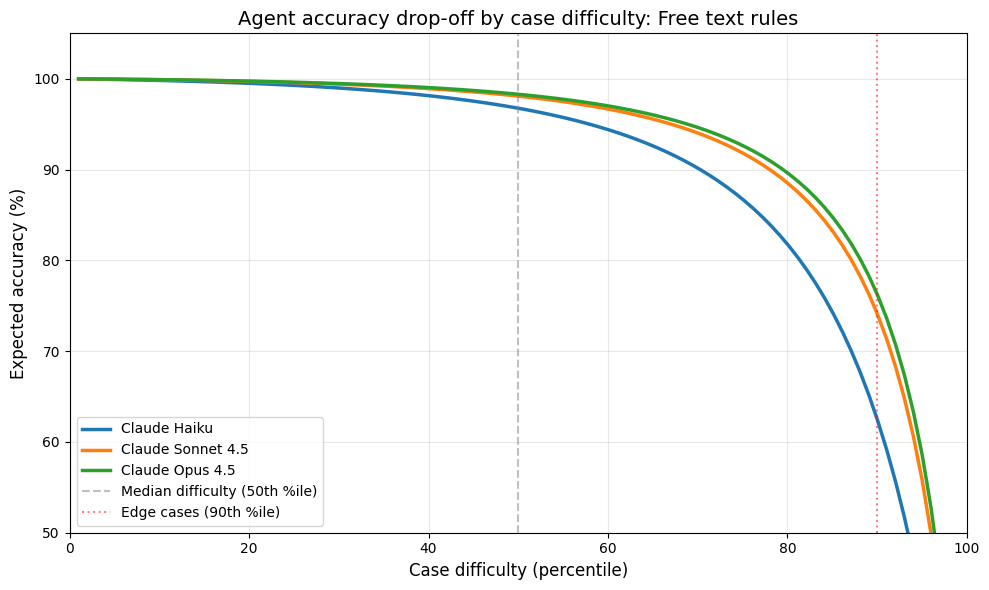

In [15]:
plot_accuracy_dropoff_by_case_difficulty(idata)

In [16]:
odds_ratios_df = compute_odds_ratios(df, posterior)


--- Effect Sizes (Odds Ratios) ---
'Free text rules' vs 'Rules via URLs': Median OR = 1.91 [1.48, 2.47]
'Free text rules' vs 'Structured spec': Median OR = 1.57 [1.21, 2.06]
'Free text rules' vs 'Training data only': Median OR = 2.43 [1.83, 3.24]
'Rules via URLs' vs 'Structured spec': Median OR = 0.82 [0.65, 1.05]
'Rules via URLs' vs 'Training data only': Median OR = 1.28 [0.98, 1.67]
'Structured spec' vs 'Training data only': Median OR = 1.55 [1.19, 2.03]


In [31]:
def plot_accuracy_dropoff_by_prompt_for_model(
    idata,
    model_name="claude-sonnet-4-5",
    prompt_types=None,
    figsize=(10, 6),
    title="Agent accuracy drop-off by case difficulty",
    ylim=(50, 105),
):
    """
    Plot expected accuracy curves across case difficulty percentiles
    for multiple prompt strategies, holding model fixed.

    Parameters
    ----------
    idata : arviz.InferenceData
        Fitted model output.
    model_name : str
        Model to fix (e.g. Sonnet).
    prompt_types : list[str] or None
        Prompt types to include. If None, inferred from posterior.
    """

    posterior = idata.posterior

    # --- Model effect (handle reference category like Haiku) ---
    model_levels = posterior["model_name"]["model_name_dim"].values.tolist()

    if model_name in model_levels:
        model_base = (
            posterior["model_name"]
            .sel(model_name_dim=model_name)
            .values
            .flatten()
            .mean()
        )
    else:
        model_base = 0.0  # reference level

    # --- Prompt types ---
    if prompt_types is None:
        prompt_types = list(
            posterior["prompt_type"]["prompt_type_dim"].values
        )

    prompt_levels = set(prompt_types)

    # --- Case difficulty spread ---
    case_intercepts = posterior["1|case_id"].values.flatten()
    case_sd = case_intercepts.std()

    percentiles = np.linspace(1, 99, 100)
    difficulty_penalties = norm.ppf(percentiles / 100, loc=0, scale=case_sd)

    # --- Compute curves ---
    curves = {}

    for prompt in prompt_types:
        if prompt in prompt_levels:
            prompt_effect = (
                posterior["prompt_type"]
                .sel(prompt_type_dim=prompt)
                .values
                .flatten()
                .mean()
            )
        else:
            prompt_effect = 0.0  # reference prompt

        curve = expit((model_base + prompt_effect) - difficulty_penalties) * 100
        curves[prompt] = curve

    # --- Tidy dataframe ---
    curves_df = pd.DataFrame({"percentile": percentiles})
    for prompt, curve in curves.items():
        curves_df[prompt] = curve

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)

    for prompt in curves:
        ax.plot(
            curves_df["percentile"],
            curves_df[prompt],
            label=prompt,
            linewidth=2.5,
        )

    ax.set_title(f"{title}: {model_name}", fontsize=14)
    ax.set_xlabel("Case difficulty (percentile)", fontsize=12)
    ax.set_ylabel("Expected accuracy (%)", fontsize=12)

    ax.axvline(
        x=50,
        color="grey",
        linestyle="--",
        alpha=0.5,
        label="Median difficulty (50th %ile)",
    )
    ax.axvline(
        x=90,
        color="red",
        linestyle=":",
        alpha=0.5,
        label="Edge cases (90th %ile)",
    )

    ax.set_xlim(0, 100)
    ax.set_ylim(*ylim)
    ax.legend(loc="lower left")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig, ax, curves_df

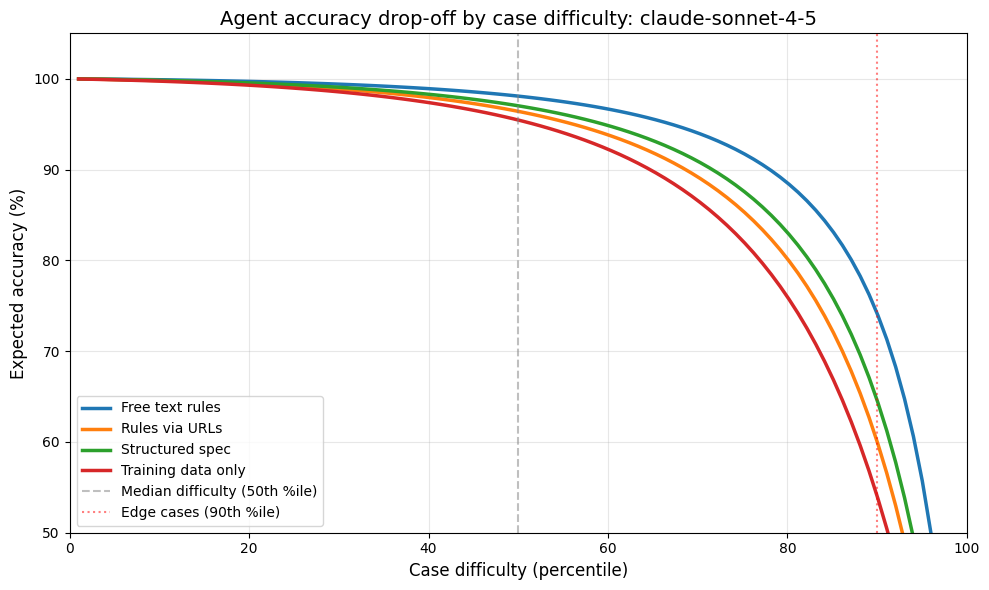

In [35]:
fig, ax, curves_df = plot_accuracy_dropoff_by_prompt_for_model(
    idata=idata,
    model_name="claude-sonnet-4-5",
)
plt.show()

In [53]:
# At 25% percentile there's basically no difference between the models
curves_df[np.abs(curves_df["percentile"]-24.8) < 1e-1]

,percentile,Free text rules,Rules via URLs,Structured spec,Training data only
24,24.757576,99.580568,99.202411,99.341723,98.982769


In [ ]:
# At 50th percentile there's a small difference between the models
curves_df[np.abs(curves_df["percentile"]-50.4) < 1e-1]

,percentile,Free text rules,Rules via URLs,Structured spec,Training data only
50,50.494949,98.031621,96.308707,96.93785,95.329708


In [55]:
# But we can see that it really drops off at 90%
curves_df[np.abs(curves_df["percentile"]-90.0) < 1e-1]

,percentile,Free text rules,Rules via URLs,Structured spec,Training data only
90,90.090909,73.935447,59.775472,64.324793,53.759302


In [17]:
def plot_prompt_strategy_by_model_separate_figs(
    idata,
    df,
    haiku_name="claude-haiku-4-5",
    sonnet_name="claude-sonnet-4-5",
    opus_name="claude-opus-4-5",
    model_labels=None,
    figsize=(10, 6),
    xlim=None,
):
    """
    This returns the estimated distribution of accuracy for a
    case of average difficulty.
    But this is not as useful as the next function which returns
    the distribution across all cases.
    Returns one figure per model with shared y-axis limits.
    """
    posterior = idata.posterior
    prompts = list(df["prompt_type"].unique())

    if model_labels is None:
        model_labels = {
            haiku_name: "Claude Haiku",
            sonnet_name: "Claude Sonnet 4.5",
            opus_name: "Claude Opus 4.5",
        }

    model_names = [haiku_name, sonnet_name, opus_name]

    model_levels = set(posterior["model_name"]["model_name_dim"].values.tolist())
    prompt_levels = set(posterior["prompt_type"]["prompt_type_dim"].values.tolist())

    n_draws = posterior.sizes["chain"] * posterior.sizes["draw"]
    zeros = np.zeros(n_draws)

    # ---------- PASS 1: compute all curves ----------
    plot_data = {}
    all_kde_maxima = []

    from scipy.stats import gaussian_kde

    for model_name in model_names:
        plot_data[model_name] = {}

        if model_name in model_levels:
            model_effect = (
                posterior["model_name"]
                .sel(model_name_dim=model_name)
                .values
                .reshape(-1)
            )
        else:
            model_effect = zeros

        for prompt in prompts:
            if prompt in prompt_levels:
                prompt_effect = (
                    posterior["prompt_type"]
                    .sel(prompt_type_dim=prompt)
                    .values
                    .reshape(-1)
                )
            else:
                prompt_effect = zeros

            log_odds = prompt_effect + model_effect
            accuracy_pct = expit(log_odds) * 100

            plot_data[model_name][prompt] = accuracy_pct

            # estimate KDE peak for shared y-limit
            kde = gaussian_kde(accuracy_pct)
            xs = np.linspace(accuracy_pct.min(), accuracy_pct.max(), 200)
            ys = kde(xs)
            all_kde_maxima.append(ys.max())

    shared_ylim = max(all_kde_maxima) * 1.1  # small padding

    # ---------- PASS 2: plotting ----------
    figs = {}

    for model_name in model_names:
        fig, ax = plt.subplots(figsize=figsize)

        for prompt in prompts:
            sns.kdeplot(
                plot_data[model_name][prompt],
                ax=ax,
                label=prompt,
                fill=True,
                alpha=0.4,
                linewidth=2,
            )

        ax.set_title(model_labels.get(model_name, model_name), fontsize=14)
        ax.set_xlabel("Estimated Accuracy (%)", fontsize=12)
        ax.set_ylabel("Certainty (Density)", fontsize=11)

        if xlim is not None:
            ax.set_xlim(*xlim)

        ax.set_ylim(0, shared_ylim)
        ax.legend(title="Prompt Type", fontsize=10, title_fontsize=11, loc="upper left")
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        figs[model_name] = fig
        plt.show()
    #return figs, plot_data

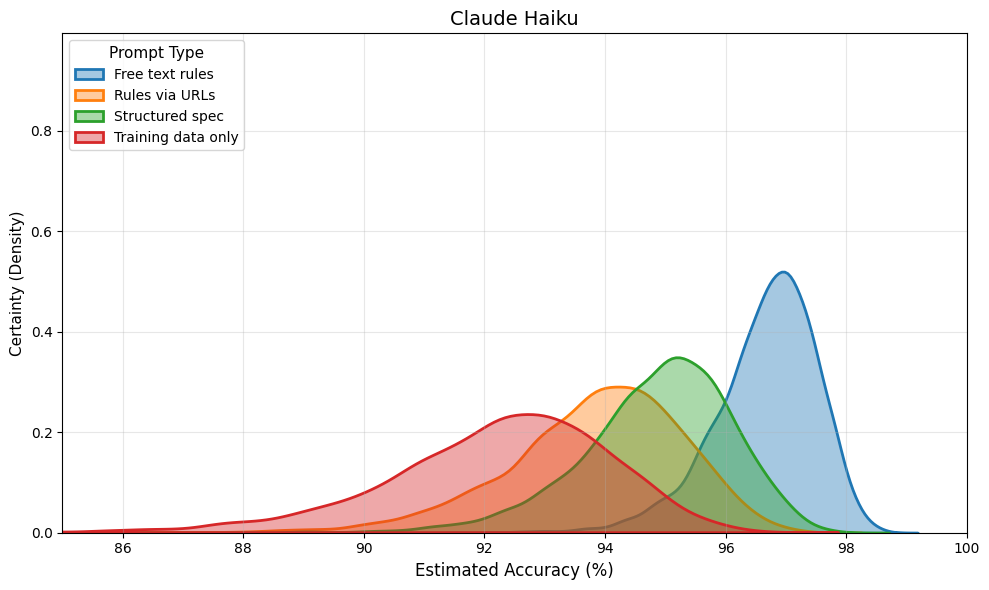

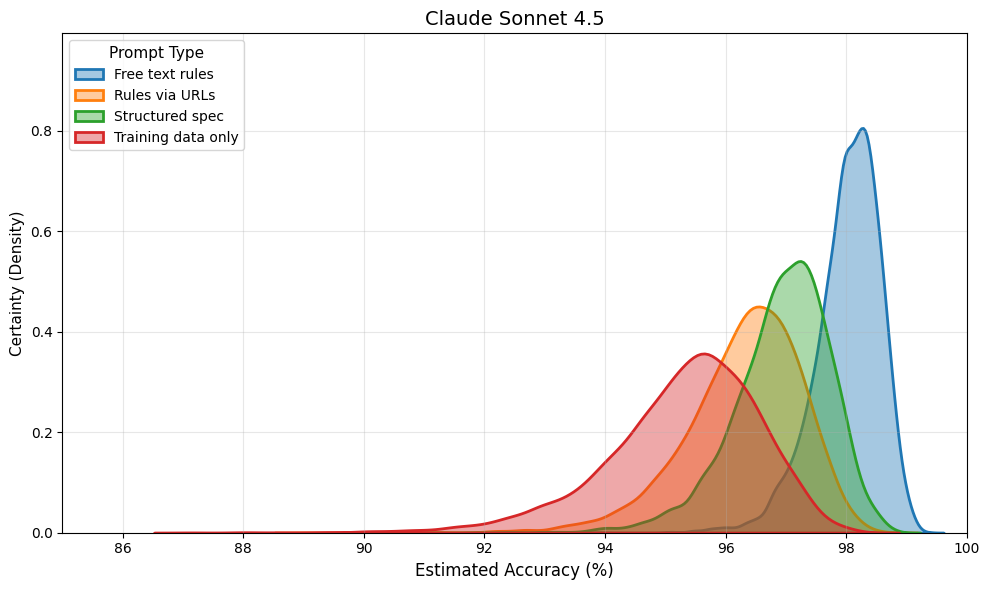

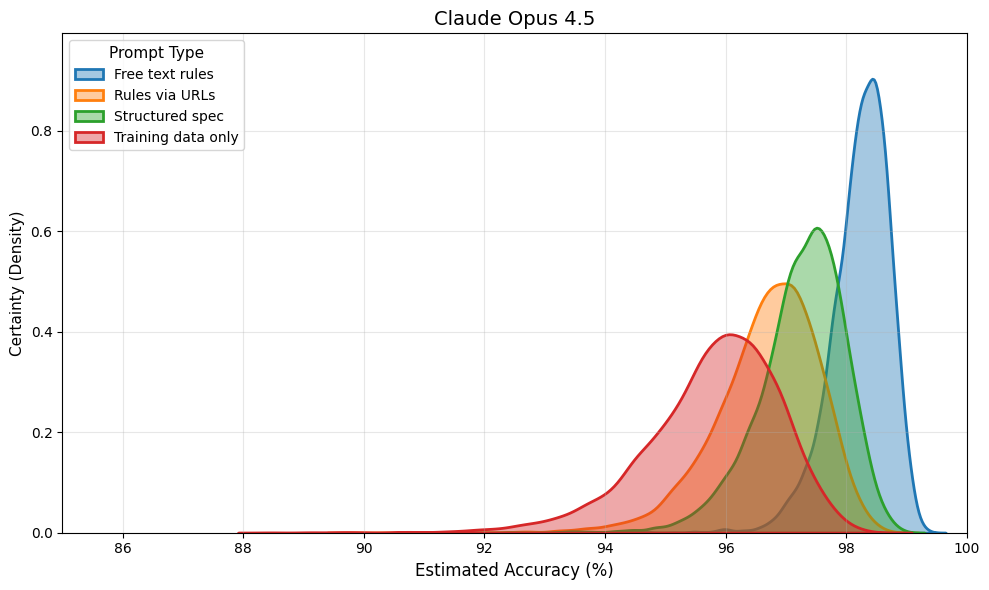

In [18]:
plot_prompt_strategy_by_model_separate_figs(
    idata=idata,
    df=df,
    xlim=(85, 100),
)

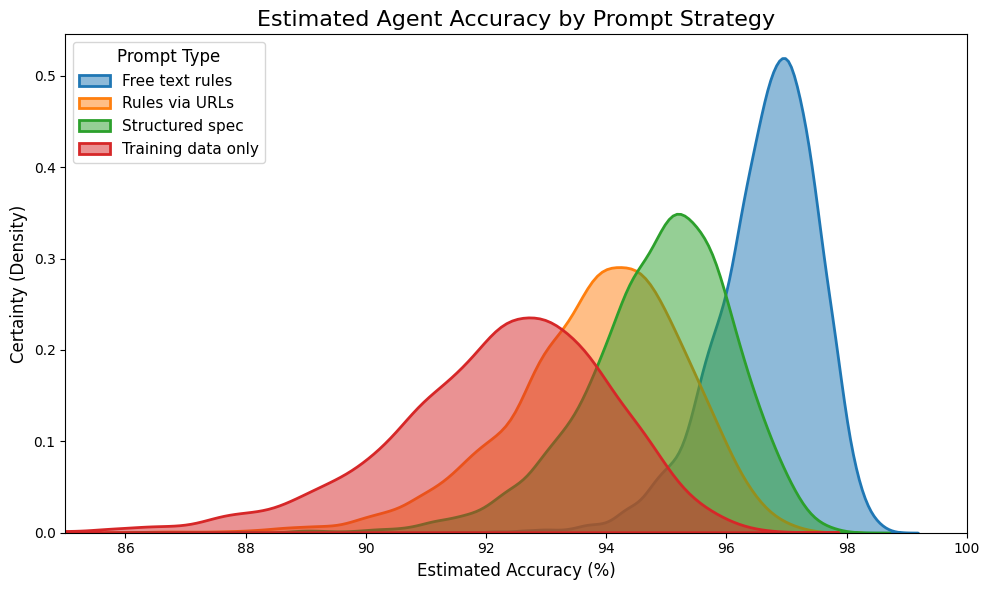

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit # This translates log-odds to probability

posterior = idata.posterior["prompt_type"]
prompts = df['prompt_type'].unique()

fig, ax = plt.subplots(figsize=(10, 6))

for p in prompts:
    # 1. Extract the raw log-odds samples
    samples_log_odds = posterior.sel(prompt_type_dim=p).values.flatten()
    
    # 2. Convert log-odds to Probability (0 to 1), then multiply by 100 for Percentage
    samples_percentage = expit(samples_log_odds) * 100
    
    # 3. Plot the new percentage-based distributions
    sns.kdeplot(samples_percentage, label=p, fill=True, alpha=0.5, linewidth=2)

plt.title("Estimated Agent Accuracy by Prompt Strategy", fontsize=16)
plt.xlabel("Estimated Accuracy (%)", fontsize=12) # Much better X-axis!
plt.ylabel("Certainty (Density)", fontsize=12)

plt.legend(title="Prompt Type", fontsize=11, title_fontsize=12, loc='upper left')

# Optional: Limit the x-axis to zoom in on the relevant high-accuracy range
plt.xlim(85, 100) 

plt.tight_layout()
plt.show()

In [20]:
def plot_mean_accuracy_by_prompt_across_cases(
    idata,
    df,
    haiku_name="claude-haiku-4-5",
    sonnet_name="claude-sonnet-4-5",
    opus_name="claude-opus-4-5",
    model_labels=None,
    figsize=(10, 6),
    xlim=None,
):
    """
    Plot posterior distributions of mean predicted accuracy across observed cases,
    separately for each model.

    For each posterior draw, predicted probabilities are computed for all observed
    cases and then averaged across cases. The KDE is then drawn over those
    draw-level mean accuracies.

    Returns
    -------
    figs : dict
        Mapping of model name -> matplotlib figure
    plot_data : dict
        Nested dict of model -> prompt -> draw-level mean predicted accuracies
    """
    posterior = idata.posterior
    prompts = list(df["prompt_type"].unique())

    if model_labels is None:
        model_labels = {
            haiku_name: "Claude Haiku",
            sonnet_name: "Claude Sonnet 4.5",
            opus_name: "Claude Opus 4.5",
        }

    model_names = [haiku_name, sonnet_name, opus_name]

    model_levels = set(posterior["model_name"]["model_name_dim"].values.tolist())
    prompt_levels = set(posterior["prompt_type"]["prompt_type_dim"].values.tolist())

    n_draws = posterior.sizes["chain"] * posterior.sizes["draw"]
    zeros = np.zeros(n_draws)

    case_effects = posterior["1|case_id"].values.reshape(n_draws, -1)

    from scipy.stats import gaussian_kde

    plot_data = {}
    all_kde_maxima = []

    # Pass 1: compute distributions and shared y-limit
    for model_name in model_names:
        plot_data[model_name] = {}

        if model_name in model_levels:
            model_effect = (
                posterior["model_name"]
                .sel(model_name_dim=model_name)
                .values
                .reshape(-1)
            )
        else:
            model_effect = zeros

        for prompt in prompts:
            if prompt in prompt_levels:
                prompt_effect = (
                    posterior["prompt_type"]
                    .sel(prompt_type_dim=prompt)
                    .values
                    .reshape(-1)
                )
            else:
                prompt_effect = zeros

            log_odds = prompt_effect[:, None] + model_effect[:, None] + case_effects
            predicted_probs = expit(log_odds) * 100

            # Mean predicted accuracy across cases for each posterior draw
            mean_accuracy = predicted_probs.mean(axis=1)
            plot_data[model_name][prompt] = mean_accuracy

            kde = gaussian_kde(mean_accuracy)
            xs = np.linspace(mean_accuracy.min(), mean_accuracy.max(), 200)
            ys = kde(xs)
            all_kde_maxima.append(ys.max())

    shared_ylim = max(all_kde_maxima) * 1.1

    # Pass 2: plot separate figures
    figs = {}

    for model_name in model_names:
        fig, ax = plt.subplots(figsize=figsize)

        for prompt in prompts:
            sns.kdeplot(
                plot_data[model_name][prompt],
                ax=ax,
                label=prompt,
                fill=True,
                alpha=0.35,
                linewidth=2,
            )

        ax.set_title(model_labels.get(model_name, model_name), fontsize=14)
        ax.set_xlabel("Mean predicted accuracy across observed cases (%)", fontsize=12)
        ax.set_ylabel("Density", fontsize=11)

        if xlim is not None:
            ax.set_xlim(*xlim)

        ax.set_ylim(0, shared_ylim)
        ax.legend(title="Prompt Type", fontsize=10, title_fontsize=11, loc="upper left")
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        figs[model_name] = fig
        plt.show()

    #return figs, plot_data

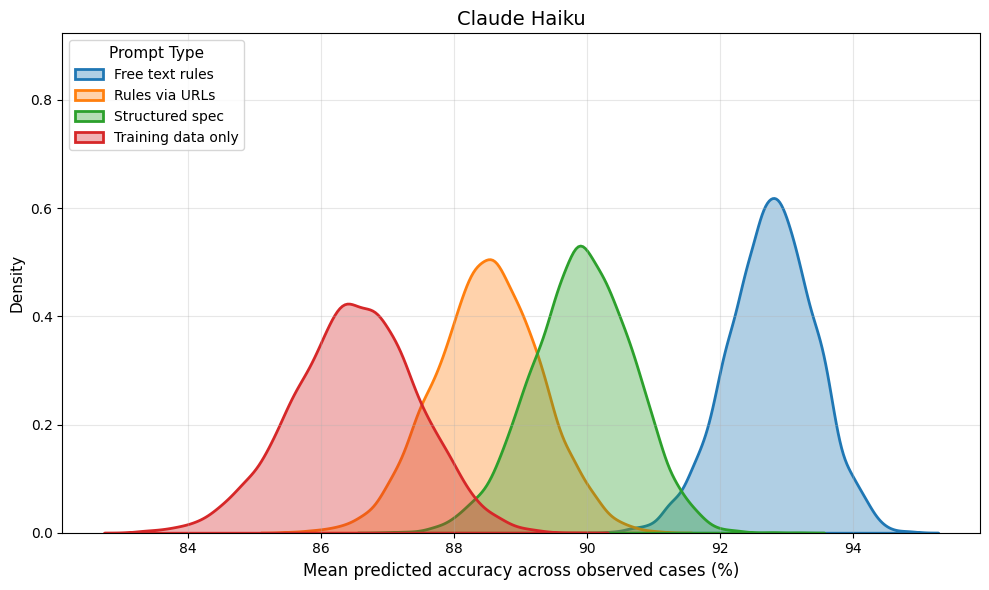

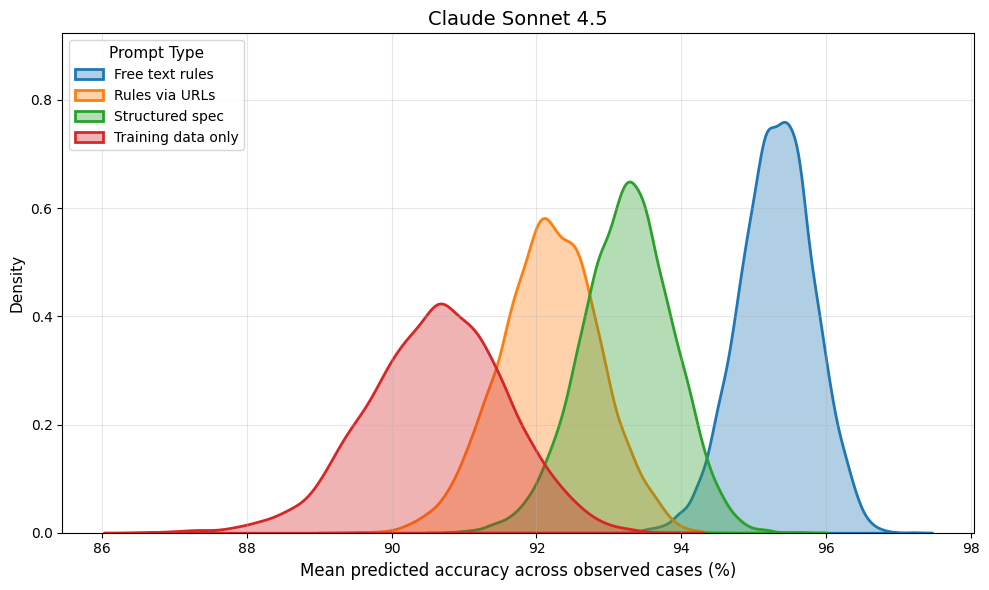

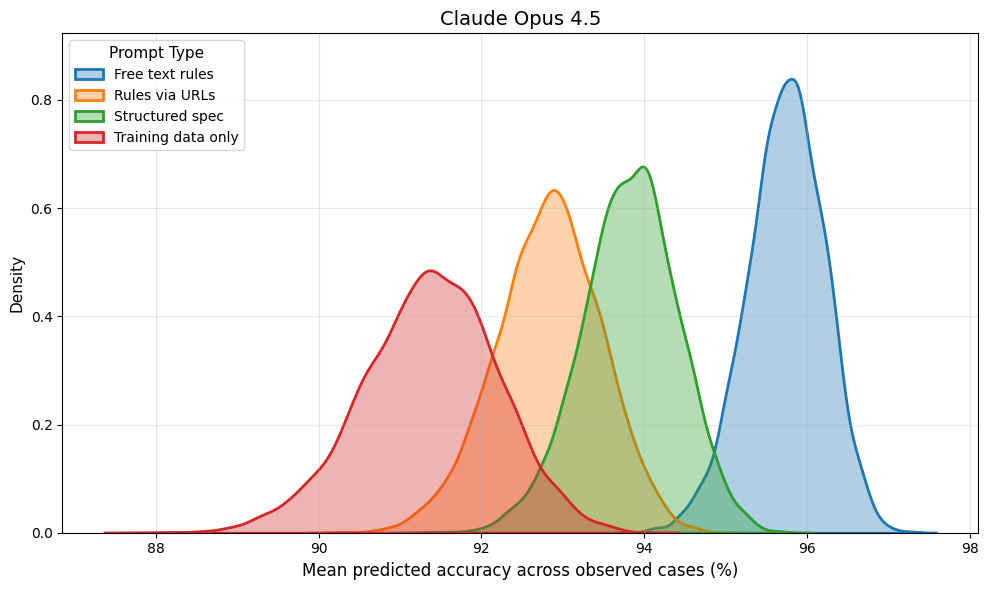

In [21]:
plot_mean_accuracy_by_prompt_across_cases(idata, df)

In [22]:
# So this is mean accuracy for a case of mean difficulty
# but I don't think that's that useful really - we're more interested
# in the distribution

# Extract the posterior samples
posterior = idata.posterior["prompt_type"]
prompts = df['prompt_type'].unique()

# Define the baseline to compare against
baseline = "Training data only"
baseline_log_odds = posterior.sel(prompt_type_dim=baseline).values.flatten()

table_data = []

for p in prompts:
    # 1. Get log-odds and convert to accuracy percentages
    log_odds = posterior.sel(prompt_type_dim=p).values.flatten()
    accuracy_samples = expit(log_odds) * 100
    
    # 2. Calculate Median and 94% High-Density Interval (Credible Interval)
    median_acc = np.median(accuracy_samples)
    hdi_lower = np.percentile(accuracy_samples, 3)
    hdi_upper = np.percentile(accuracy_samples, 97)
    
    # 3. Calculate Odds Ratio vs Baseline
    odds_ratio = np.median(np.exp(log_odds - baseline_log_odds))
    
    # 4. Calculate Probability of being better than the baseline
    if p == baseline:
        prob_better = np.nan
    else:
        prob_better = np.mean(log_odds > baseline_log_odds) * 100
        
    # Append to our list
    table_data.append({
        "Prompt Strategy": p,
        "Est. Accuracy": f"{median_acc:.1f}%",
        "94% Credible Interval": f"[{hdi_lower:.1f}%, {hdi_upper:.1f}%]",
        "Odds Ratio (vs Baseline)": "-" if p == baseline else f"{odds_ratio:.2f}x",
        "Prob. > Baseline": "-" if p == baseline else f"{prob_better:.1f}%"
    })

# Convert to a DataFrame and sort by Accuracy
results_df = pd.DataFrame(table_data)
results_df = results_df.sort_values(by="Est. Accuracy", ascending=False).reset_index(drop=True)

# Display the clean table
print(results_df.to_string(index=False))

   Prompt Strategy Est. Accuracy 94% Credible Interval Odds Ratio (vs Baseline) Prob. > Baseline
   Free text rules         96.8%        [94.7%, 98.0%]                    2.43x           100.0%
   Structured spec         95.0%        [92.1%, 96.8%]                    1.55x            99.9%
    Rules via URLs         94.0%        [90.6%, 96.2%]                    1.28x            96.4%
Training data only         92.4%        [88.1%, 95.1%]                        -                -


In [23]:
results_df

,Prompt Strategy,Est. Accuracy,94% Credible Interval,Odds Ratio (vs Baseline),Prob. > Baseline
0,Free text rules,96.8%,"[94.7%, 98.0%]",2.43x,100.0%
1,Structured spec,95.0%,"[92.1%, 96.8%]",1.55x,99.9%
2,Rules via URLs,94.0%,"[90.6%, 96.2%]",1.28x,96.4%
3,Training data only,92.4%,"[88.1%, 95.1%]",-,-


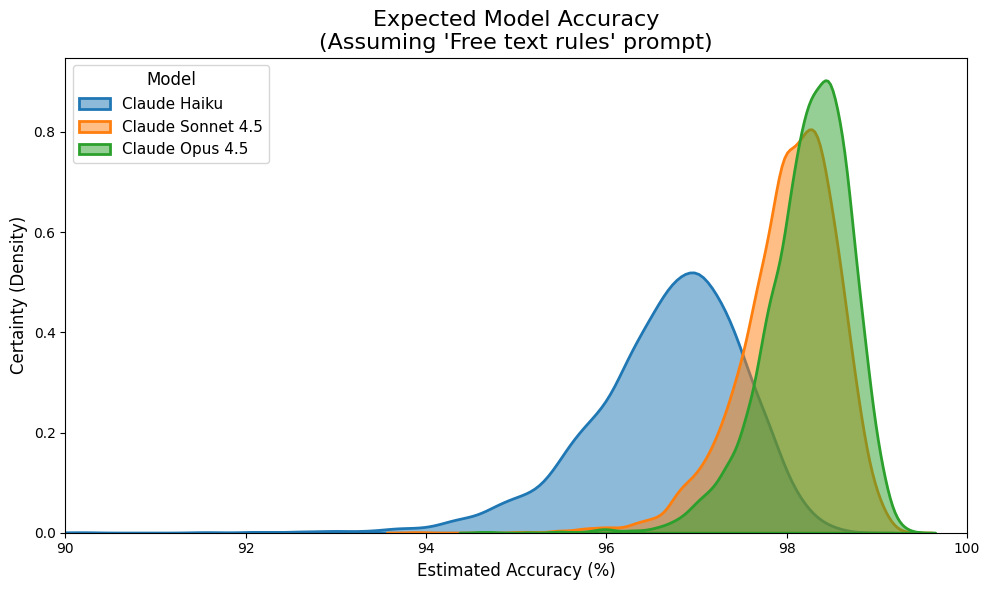

In [24]:

# 1. Extract the relative model effects from the posterior
sonnet_effect = idata.posterior["model_name"].sel(model_name_dim="claude-sonnet-4-5").values.flatten()
opus_effect = idata.posterior["model_name"].sel(model_name_dim="claude-opus-4-5").values.flatten()

# Haiku was the reference category in the regression, so its effect is 0
haiku_effect = np.zeros_like(sonnet_effect) 

# 2. Extract our anchor (The log-odds of the winning 'Free text rules' prompt)
anchor_log_odds = idata.posterior["prompt_type"].sel(prompt_type_dim="Free text rules").values.flatten()

# 3. Combine them to get absolute log-odds for each model
models_log_odds = {
    "Claude Haiku": anchor_log_odds + haiku_effect,
    "Claude Sonnet 4.5": anchor_log_odds + sonnet_effect,
    "Claude Opus 4.5": anchor_log_odds + opus_effect
}

# 4. Plotting
fig, ax = plt.subplots(figsize=(10, 6))

for model_name, log_odds in models_log_odds.items():
    # Convert log-odds to Percentage Accuracy
    accuracy_percentage = expit(log_odds) * 100
    sns.kdeplot(accuracy_percentage, label=model_name, fill=True, alpha=0.5, linewidth=2)

plt.title("Expected Model Accuracy\n(Assuming 'Free text rules' prompt)", fontsize=16)
plt.xlabel("Estimated Accuracy (%)", fontsize=12)
plt.ylabel("Certainty (Density)", fontsize=12)
plt.legend(title="Model", fontsize=11, title_fontsize=12, loc='upper left')

# Zoom in on the high accuracy range
plt.xlim(90, 100) 
plt.tight_layout()
plt.show()

In [25]:
import pandas as pd

table_data = []
baseline_name = "Claude Haiku"
baseline_log_odds = models_log_odds[baseline_name]

for model_name, log_odds in models_log_odds.items():
    # Convert to accuracy percentages
    accuracy_samples = expit(log_odds) * 100
    
    # Calculate Median and 94% HDI
    median_acc = np.median(accuracy_samples)
    hdi_lower = np.percentile(accuracy_samples, 3)
    hdi_upper = np.percentile(accuracy_samples, 97)
    
    # Calculate Odds Ratio vs Haiku
    # (We calculate this using the raw effect sizes to isolate the model's power)
    odds_ratio = np.median(np.exp(log_odds - baseline_log_odds))
    
    # Calculate Probability of being better than Haiku
    if model_name == baseline_name:
        prob_better = np.nan
    else:
        prob_better = np.mean(log_odds > baseline_log_odds) * 100
        
    table_data.append({
        "Model": model_name,
        "Est. Accuracy (w/ Free Text)": f"{median_acc:.1f}%",
        "94% Credible Interval": f"[{hdi_lower:.1f}%, {hdi_upper:.1f}%]",
        "Odds Ratio (vs Haiku)": "-" if model_name == baseline_name else f"{odds_ratio:.2f}x",
        "Prob. > Haiku": "-" if model_name == baseline_name else f"{prob_better:.1f}%"
    })

# Convert to a DataFrame and sort by Accuracy
model_results_df = pd.DataFrame(table_data)
model_results_df = model_results_df.sort_values(by="Est. Accuracy (w/ Free Text)", ascending=False).reset_index(drop=True)

print(model_results_df.to_string(index=False))

            Model Est. Accuracy (w/ Free Text) 94% Credible Interval Odds Ratio (vs Haiku) Prob. > Haiku
  Claude Opus 4.5                        98.3%        [97.2%, 99.0%]                 1.93x        100.0%
Claude Sonnet 4.5                        98.1%        [96.8%, 98.8%]                 1.72x        100.0%
     Claude Haiku                        96.8%        [94.7%, 98.0%]                     -             -


In [26]:


# 1. Standardize the column names for the Prompt results
results_df = results_df.rename(columns={
    "Prompt Strategy": "Level",
    "Prob. > Baseline": "P(> Baseline)"
})
results_df.insert(0, "Variable", "Prompt Strategy")

# 2. Standardize the column names for the Model results
model_results_df = model_results_df.rename(columns={
    "Model": "Level", 
    "Est. Accuracy (w/ Free Text)": "Est. Accuracy",
    "Odds Ratio (vs Haiku)": "Odds Ratio (vs Baseline)",
    "Prob. > Haiku": "P(> Baseline)"
})
model_results_df.insert(0, "Variable", "Base Model")

# 3. Concatenate them together
final_table = pd.concat([results_df, model_results_df], ignore_index=True)

# 4. Create a MultiIndex to give it that "Regression Output" nested look
final_table = final_table.set_index(["Variable", "Level"])

# Print the final result
print(final_table.to_string())

                                   Est. Accuracy 94% Credible Interval Odds Ratio (vs Baseline) P(> Baseline)
Variable        Level                                                                                        
Prompt Strategy Free text rules            96.8%        [94.7%, 98.0%]                    2.43x        100.0%
                Structured spec            95.0%        [92.1%, 96.8%]                    1.55x         99.9%
                Rules via URLs             94.0%        [90.6%, 96.2%]                    1.28x         96.4%
                Training data only         92.4%        [88.1%, 95.1%]                        -             -
Base Model      Claude Opus 4.5            98.3%        [97.2%, 99.0%]                    1.93x        100.0%
                Claude Sonnet 4.5          98.1%        [96.8%, 98.8%]                    1.72x        100.0%
                Claude Haiku               96.8%        [94.7%, 98.0%]                        -             -


In [27]:
final_table

Est. Accuracy 94% Credible Interval  \
Variable        Level                                                    
Prompt Strategy Free text rules            96.8%        [94.7%, 98.0%]   
                Structured spec            95.0%        [92.1%, 96.8%]   
                Rules via URLs             94.0%        [90.6%, 96.2%]   
                Training data only         92.4%        [88.1%, 95.1%]   
Base Model      Claude Opus 4.5            98.3%        [97.2%, 99.0%]   
                Claude Sonnet 4.5          98.1%        [96.8%, 98.8%]   
                Claude Haiku               96.8%        [94.7%, 98.0%]   

                                   Odds Ratio (vs Baseline) P(> Baseline)  
Variable        Level                                                      
Prompt Strategy Free text rules                       2.43x        100.0%  
                Structured spec                       1.55x         99.9%  
                Rules via URLs                        1.28x         96.4%  
                Training data only                        -             -  
Base Model      Claude Opus 4.5                       1.93x        100.0%  
                Claude Sonnet 4.5                     1.72x        100.0%  
                Claude Haiku                              -             -